# Serie A Prediction Model

Questo notebook prepara e analizza dati relativi a giocatori, squadre e partite di Serie A, con l'obiettivo di costruire variabili utili per un modello predittivo.

## Importazione delle librerie

In questa sezione vengono importate le librerie principali utilizzate per l'analisi dei dati.

- `pandas` viene utilizzata per caricare, filtrare e manipolare i dataset in formato tabellare.
- `numpy` viene utilizzata per operazioni numeriche e gestione di array.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Caricamento e selezione dei giocatori di Serie A

Il file `players.csv` contiene informazioni anagrafiche e sportive sui calciatori presenti nel dataset.

In questa fase vengono selezionati soltanto i giocatori appartenenti alla competizione italiana, identificata dal codice `IT1`, corrispondente alla Serie A.

Vengono inoltre mantenuti solo i giocatori con `last_season` successiva al 2024, così da lavorare sui calciatori più recenti e coerenti con l'obiettivo di analizzare la stagione attuale.

Infine, viene salvato nella variabile `ids` l'elenco degli identificativi dei giocatori selezionati, che sarà riutilizzato per filtrare altri dataset.

In [28]:
players = pd.read_csv('tables/players.csv')
seriea_players = players[(players.current_club_domestic_competition_id == 'IT1') & (players.last_season > 2024)]
ids = seriea_players.player_id
seriea_players

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,contract_expiration_date,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
1299,15452,Raúl,Albiol,Raúl Albiol,2025,4172,raul-albiol,Spain,Vilamarxant,Spain,1985-09-04 00:00:00,Centre-Back,Defender,right,190.0,2026-06-30 00:00:00,LP Sport Management,https://img.a.transfermarkt.technology/portrai...,58.0,0.0,NaN,https://www.transfermarkt.co.uk/raul-albiol/pr...,IT1,Pisa Sporting Club,800000.0,18000000.0
2342,27807,Daniele,Padelli,Daniele Padelli,2025,410,daniele-padelli,Italy,Lecco,Italy,1985-10-25 00:00:00,Goalkeeper,Goalkeeper,right,191.0,2027-06-30 00:00:00,Mondial,https://img.a.transfermarkt.technology/portrai...,0.0,0.0,NaN,https://www.transfermarkt.co.uk/daniele-padell...,IT1,Udinese Calcio,150000.0,2000000.0
2354,27992,Luka,Modrić,Luka Modrić,2025,5,luka-modric,Jugoslawien (SFR),Zadar,Croatia,1985-09-09 00:00:00,Central Midfield,Midfield,right,172.0,2026-06-30 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,198.0,29.0,NaN,https://www.transfermarkt.co.uk/luka-modric/pr...,IT1,Associazione Calcio Milan,4000000.0,55000000.0
2757,33571,Lorenzo,De Silvestri,Lorenzo De Silvestri,2025,1025,lorenzo-de-silvestri,Italy,Roma,Italy,1988-05-23 00:00:00,Right-Back,Defender,right,187.0,2026-06-30 00:00:00,Sergio Berti,https://img.a.transfermarkt.technology/portrai...,6.0,0.0,NaN,https://www.transfermarkt.co.uk/lorenzo-de-sil...,IT1,Bologna Football Club 1909,400000.0,6000000.0
3579,42205,Yann,Sommer,Yann Sommer,2025,46,yann-sommer,Switzerland,Morges,Switzerland,1988-12-17 00:00:00,Goalkeeper,Goalkeeper,right,183.0,2026-06-30 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,94.0,0.0,NaN,https://www.transfermarkt.co.uk/yann-sommer/pr...,IT1,Football Club Internazionale Milano S.p.A.,2500000.0,13000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46188,1259706,Henrique,Menke,Henrique Menke,2025,1047,henrique-menke,Brazil,Balneário Camboriú,Brazil,2007-01-12 00:00:00,Goalkeeper,Goalkeeper,right,190.0,2026-06-30 00:00:00,N29,https://img.a.transfermarkt.technology/portrai...,0.0,0.0,NaN,https://www.transfermarkt.co.uk/henrique-menke...,IT1,Calcio Como,NaN,NaN
46606,1300966,Branimir,Mlacic,Branimir Mlacic,2025,410,branimir-mlacic,Croatia,Split,Croatia,2007-03-12 00:00:00,Centre-Back,Defender,right,192.0,2031-06-30 00:00:00,LIAN Sports Group,https://img.a.transfermarkt.technology/portrai...,3.0,1.0,NaN,https://www.transfermarkt.co.uk/branimir-mlaci...,IT1,Udinese Calcio,NaN,NaN
46768,1315458,Fallou,Cham,Fallou Cham,2025,276,fallou-cham,NaN,NaN,The Gambia,2006-02-14 00:00:00,Right-Back,Defender,right,185.0,NaN,Dream and Goal,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/fallou-cham/pr...,IT1,Verona Hellas Football Club,NaN,NaN
46959,1355285,NaN,Arthur Borghi,Arthur Borghi,2025,276,arthur-borghi,Brazil,Campo Mourão,Brazil,2007-07-27 00:00:00,Goalkeeper,Goalkeeper,NaN,194.0,2029-06-30 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/arthur-borghi/...,IT1,Verona Hellas Football Club,NaN,NaN


## Caricamento e selezione delle squadre di Serie A

In questa sezione viene caricato il file `clubs.csv`, che contiene informazioni relative alle società calcistiche presenti nel dataset.

Il dataset viene filtrato mantenendo soltanto le squadre appartenenti alla competizione italiana di Serie A, identificata dal codice `IT1`.

Vengono considerate solo le squadre con `last_season` maggiore di 2024, in modo da selezionare i club presenti nella stagione più recente del campionato.

Le variabili contenute in questa tabella permettono di descrivere caratteristiche generali delle squadre, come identificativo, nome, rosa, valore di mercato e altri attributi societari.

In [29]:
teams = pd.read_csv('tables/clubs.csv')
seriea_teams = teams[(teams.domestic_competition_id == 'IT1') & (teams.last_season > 2024)]
seriea_teams

,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
4,1005,us-lecce,Unione Sportiva Lecce,IT1,NaN,27,25.3,23,85.2,13,Ettore Giardiniero,31559,+€8.62m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/us-lecce/start...
12,1025,fc-bologna,Bologna Football Club 1909,IT1,NaN,27,27.4,17,63.0,11,Stadio Renato Dall’Ara,36462,+€27.70m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/fc-bologna/sta...
21,1047,como-1907,Calcio Como,IT1,NaN,27,26.4,25,92.6,10,Giuseppe Sinigaglia,12039,€-110.51m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/como-1907/star...
87,12,as-rom,Associazione Sportiva Roma,IT1,NaN,27,26.3,19,70.4,13,Olimpico di Roma,70634,€-24.45m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/as-rom/startse...
115,130,parma-calcio-1913,Parma Calcio 1913,IT1,NaN,25,24.7,19,76.0,2,Ennio Tardini,22352,+€42.29m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/parma-calcio-1...
126,1390,cagliari-calcio,Cagliari Calcio,IT1,NaN,29,25.6,14,48.3,6,Unipol Domus,16416,+€800k,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/cagliari-calci...
236,2239,us-cremonese,Unione Sportiva Cremonese S.p.A.,IT1,NaN,27,28.6,12,44.4,3,Giovanni Zini,16003,€-17.75m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/us-cremonese/s...
291,252,genua-cfc,Genoa Cricket and Football Club,IT1,NaN,26,26.8,18,69.2,8,Luigi Ferraris,34901,+€47.93m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/genua-cfc/star...
326,276,hellas-verona,Verona Hellas Football Club,IT1,NaN,30,26.0,26,86.7,9,Marcantonio Bentegodi,39211,+€7.30m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/hellas-verona/...
467,398,lazio-rom,Società Sportiva Lazio S.p.A.,IT1,NaN,28,27.8,17,60.7,11,Olimpico di Roma,70634,+€13.55m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/lazio-rom/star...


## Selezione delle ultime valutazioni di mercato dei giocatori

In questa sezione viene caricato il file `player_valuations.csv`, che contiene le valutazioni di mercato dei giocatori nel tempo.

Poiché ogni giocatore può avere più valutazioni associate a date diverse, il dataset viene prima filtrato mantenendo soltanto i giocatori di Serie A selezionati in precedenza.

La colonna `date` viene convertita in formato datetime, così da poter ordinare e confrontare correttamente le date delle valutazioni.

Per ogni giocatore viene quindi selezionata la valutazione più recente disponibile, salvata nel dataframe `latest_ratings`.

In [30]:
ratings = pd.read_csv('tables/player_valuations.csv')
ratings["date"] = pd.to_datetime(ratings['date'])
relevant_ratings = ratings[(ratings.player_id.isin(ids))]
latest_ratings = relevant_ratings.loc[
    relevant_ratings.groupby("player_id")["date"].idxmax()
]
latest_ratings
ratings

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057,BE1
1,342216,2001-07-20,100000,Unknown,1241,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1
3,6893,2003-12-15,900000,Galatasaray,984,GB1
4,10,2004-10-04,7000000,SV Werder Bremen,398,IT1
...,...,...,...,...,...,...
507810,922783,2026-01-24,25000,Asteras Aktor B,120649,NaN
507811,1175508,2026-01-29,50000,Eyüpspor,7160,TR1
507812,439343,2026-02-11,1200000,Johor Darul Ta'zim,15817,NaN
507813,1133978,2026-02-13,250000,FC Lausanne-Sport,527,C1


### Verifica di coerenza delle valutazioni

Questa cella confronta i valori di mercato più recenti estratti da `player_valuations.csv` con i valori già presenti nella tabella `players.csv`.

Il risultato booleano permette di verificare se le due fonti riportano la stessa sequenza di valori per i giocatori considerati, escludendo i valori mancanti nella tabella dei giocatori.

In [31]:
np.array_equal(latest_ratings["market_value_in_eur"].values, (seriea_players.market_value_in_eur[~seriea_players.market_value_in_eur.isna()].values))

True

## Selezione degli eventi rilevanti

In questa sezione vengono selezionati gli eventi di gioco associati ai giocatori di Serie A.

Il filtro viene costruito verificando se il `player_id` presente nella tabella degli eventi appartiene all'elenco `ids`, che contiene gli identificativi dei giocatori selezionati dalla tabella `players.csv`.

La colonna `date` viene convertita in formato datetime, così da poter applicare correttamente un filtro temporale.

Infine, vengono mantenuti solo gli eventi successivi al 2020, in modo da concentrare l'analisi sulle stagioni più recenti.

In [32]:
events = pd.read_csv('tables/game_events.csv')
mask = events["player_id"].isin(ids)
events["date"] = pd.to_datetime(events["date"])
relevant_events = events[mask & (events.date.dt.year > 2020)]
relevant_events

,game_event_id,date,game_id,minute,type,club_id,club_name,player_id,description,player_in_id,player_assist_id
576638,a4af19d9418e14a3c9864d35808c0760,2021-06-11,3287199,85,Substitutions,3376,Italy,177843,", Injury",197300.0,NaN
576640,426a7c534adc738a9b70c7d6d7c30377,2021-06-11,3287199,74,Substitutions,3376,Italy,265088,", Tactical",199248.0,NaN
576657,ca77d03879224f952572075b0c762e30,2021-06-12,3287201,10,Goals,3382,Belgium,96341,", Left-footed shot, 1. Tournament Goal Assist:...",NaN,56416.0
576658,065757152757dbebf3752851a2a0c055,2021-06-12,3287201,88,Goals,3382,Belgium,96341,", Right-footed shot, 2. Tournament Goal Assist...",NaN,100986.0
576689,492b5f64bbd2e0ea6be550f82da8f65e,2021-06-13,3287203,85,Goals,3379,Netherlands,321528,", Header, 1. Tournament Goal Assist: , Cross, ...",NaN,177476.0
...,...,...,...,...,...,...,...,...,...,...,...
1270456,2f55177cd8e3be679b81b003b48c32b4,2026-05-13,4869248,77,Substitutions,46,Inter Milan,406625,", Tactical",827734.0,NaN
1270457,0bc2a1a8c99a5f3dc69c5c7deb17ebc3,2026-05-13,4869248,6,Cards,46,Inter Milan,441986,"1. Yellow card , Foul",NaN,NaN
1270458,d597922b412376b51ae133959d6b6326,2026-05-13,4869248,66,Substitutions,398,SS Lazio,462823,", Tactical",550106.0,NaN
1270459,da67584aab0b248031bf9c7e48707ccb,2026-05-13,4869248,38,Cards,398,SS Lazio,618341,"2. Yellow card , Foul",NaN,NaN


## Collegamento tra eventi e giocatori

In questa fase il dataset degli eventi viene collegato alla tabella dei giocatori di Serie A.

Il collegamento viene effettuato tramite la variabile `player_id`, presente sia nella tabella degli eventi sia nella tabella dei giocatori.

L'obiettivo è arricchire il dataset degli eventi aggiungendo il nome del giocatore coinvolto in ciascun evento. In questo modo la tabella diventa più leggibile e più semplice da interpretare durante l'analisi esplorativa.

In [33]:
relevant_events = relevant_events.merge(
    seriea_players[["player_id", "name"]],
    on="player_id",
    how="left"
)
relevant_events

,game_event_id,date,game_id,minute,type,club_id,club_name,player_id,description,player_in_id,player_assist_id,name
0,a4af19d9418e14a3c9864d35808c0760,2021-06-11,3287199,85,Substitutions,3376,Italy,177843,", Injury",197300.0,NaN,Domenico Berardi
1,426a7c534adc738a9b70c7d6d7c30377,2021-06-11,3287199,74,Substitutions,3376,Italy,265088,", Tactical",199248.0,NaN,Manuel Locatelli
2,ca77d03879224f952572075b0c762e30,2021-06-12,3287201,10,Goals,3382,Belgium,96341,", Left-footed shot, 1. Tournament Goal Assist:...",NaN,56416.0,Romelu Lukaku
3,065757152757dbebf3752851a2a0c055,2021-06-12,3287201,88,Goals,3382,Belgium,96341,", Right-footed shot, 2. Tournament Goal Assist...",NaN,100986.0,Romelu Lukaku
4,492b5f64bbd2e0ea6be550f82da8f65e,2021-06-13,3287203,85,Goals,3379,Netherlands,321528,", Header, 1. Tournament Goal Assist: , Cross, ...",NaN,177476.0,Denzel Dumfries
...,...,...,...,...,...,...,...,...,...,...,...,...
32394,2f55177cd8e3be679b81b003b48c32b4,2026-05-13,4869248,77,Substitutions,46,Inter Milan,406625,", Tactical",827734.0,NaN,Lautaro Martínez
32395,0bc2a1a8c99a5f3dc69c5c7deb17ebc3,2026-05-13,4869248,6,Cards,46,Inter Milan,441986,"1. Yellow card , Foul",NaN,NaN,Yann Bisseck
32396,d597922b412376b51ae133959d6b6326,2026-05-13,4869248,66,Substitutions,398,SS Lazio,462823,", Tactical",550106.0,NaN,Gustav Isaksen
32397,da67584aab0b248031bf9c7e48707ccb,2026-05-13,4869248,38,Cards,398,SS Lazio,618341,"2. Yellow card , Foul",NaN,NaN,Mario Gila


## Caricamento e selezione delle partite di Serie A

Il file `games.csv` contiene le informazioni sulle partite presenti nel dataset.

In questa fase vengono selezionate solo le partite della competizione `IT1` con stagione successiva al 2020. La cella rimuove poi alcune colonne descrittive o non necessarie per l'analisi, come URL, arbitro, allenatori e moduli di gioco.

In [34]:
games = pd.read_csv('tables/games.csv')
relevant_games = games[(games.competition_id == 'IT1') & (games.season > 2020)]
relevant_games.drop(['competition_type', 'home_club_formation', 'away_club_formation', 'url', 'referee', 'home_club_manager_name', 'away_club_manager_name', 'competition_id'], axis='columns')

,game_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,away_club_position,stadium,attendance,home_club_name,away_club_name,aggregate
54640,3614505,2021,1. Matchday,2021-08-22,1025,380,3,2,6.0,13.0,Stadio Renato Dall’Ara,8375.0,Bologna Football Club 1909,US Salernitana 1919,3:2
54641,3614506,2021,1. Matchday,2021-08-23,1390,3522,2,2,9.0,11.0,Unipol Domus,5387.0,Cagliari Calcio,Spezia Calcio,2:2
54642,3614507,2021,1. Matchday,2021-08-21,749,398,1,3,18.0,3.0,Carlo Castellani,3655.0,FC Empoli,Società Sportiva Lazio S.p.A.,1:3
54643,3614508,2021,1. Matchday,2021-08-21,276,6574,2,3,14.0,5.0,Marcantonio Bentegodi,5448.0,Verona Hellas Football Club,Unione Sportiva Sassuolo Calcio,2:3
54644,3614509,2021,1. Matchday,2021-08-21,46,252,4,0,1.0,20.0,Giuseppe Meazza,27402.0,Football Club Internazionale Milano S.p.A.,Genoa Cricket and Football Club,4:0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79666,4621093,2025,38. Matchday,2026-05-24,5,1390,1,2,5.0,14.0,Giuseppe Meazza,74539.0,Associazione Calcio Milan,Cagliari Calcio,1:2
79667,4621094,2025,38. Matchday,2026-05-24,6195,410,1,0,2.0,10.0,Diego Armando Maradona,50000.0,Società Sportiva Calcio Napoli,Udinese Calcio,1:0
79668,4621095,2025,38. Matchday,2026-05-24,130,6574,1,0,13.0,11.0,Ennio Tardini,17369.0,Parma Calcio 1913,Unione Sportiva Sassuolo Calcio,1:0
79669,4621096,2025,38. Matchday,2026-05-24,416,506,2,2,12.0,6.0,Olimpico Grande Torino,26000.0,Torino Calcio,Juventus Football Club,2:2


## Anteprima delle variabili principali delle squadre

Questa cella mostra una versione alleggerita della tabella delle squadre di Serie A.

Vengono escluse alcune colonne amministrative o poco utili per le analisi successive, così da visualizzare più chiaramente gli attributi principali dei club selezionati.

In [35]:
seriea_teams.drop(['club_code', 'domestic_competition_id', 'stadium_name', 'last_season', 'filename', 'url', 'coach_name'], axis='columns')

,club_id,name,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_seats,net_transfer_record
4,1005,Unione Sportiva Lecce,NaN,27,25.3,23,85.2,13,31559,+€8.62m
12,1025,Bologna Football Club 1909,NaN,27,27.4,17,63.0,11,36462,+€27.70m
21,1047,Calcio Como,NaN,27,26.4,25,92.6,10,12039,€-110.51m
87,12,Associazione Sportiva Roma,NaN,27,26.3,19,70.4,13,70634,€-24.45m
115,130,Parma Calcio 1913,NaN,25,24.7,19,76.0,2,22352,+€42.29m
126,1390,Cagliari Calcio,NaN,29,25.6,14,48.3,6,16416,+€800k
236,2239,Unione Sportiva Cremonese S.p.A.,NaN,27,28.6,12,44.4,3,16003,€-17.75m
291,252,Genoa Cricket and Football Club,NaN,26,26.8,18,69.2,8,34901,+€47.93m
326,276,Verona Hellas Football Club,NaN,30,26.0,26,86.7,9,39211,+€7.30m
467,398,Società Sportiva Lazio S.p.A.,NaN,28,27.8,17,60.7,11,70634,+€13.55m


## Selezione delle squadre di Serie A negli ultimi cinque anni

In questa fase viene ricostruito l'elenco delle squadre che hanno partecipato alla Serie A nelle stagioni più recenti.

Il file `clubs.csv` viene caricato nuovamente e filtrato mantenendo i club con `domestic_competition_id` uguale a `IT1` e `last_season` successiva al 2020.

Questo insieme di squadre verrà usato come base per associare i valori di mercato ai club apparsi nel campionato durante il periodo analizzato.

In [36]:
teams = pd.read_csv('tables/clubs.csv')
seriea_teams_last5 = teams[(teams.domestic_competition_id == 'IT1') & (teams.last_season > 2020)]
seriea_teams_last5

,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
4,1005,us-lecce,Unione Sportiva Lecce,IT1,NaN,27,25.3,23,85.2,13,Ettore Giardiniero,31559,+€8.62m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/us-lecce/start...
12,1025,fc-bologna,Bologna Football Club 1909,IT1,NaN,27,27.4,17,63.0,11,Stadio Renato Dall’Ara,36462,+€27.70m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/fc-bologna/sta...
17,1038,sampdoria-genua,UC Sampdoria,IT1,NaN,33,24.3,5,15.6,4,Luigi Ferraris,36348,+€1.75m,NaN,2022,../data/raw/transfermarkt-scraper/2022/clubs.j...,https://www.transfermarkt.co.uk/sampdoria-genu...
21,1047,como-1907,Calcio Como,IT1,NaN,27,26.4,25,92.6,10,Giuseppe Sinigaglia,12039,€-110.51m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/como-1907/star...
87,12,as-rom,Associazione Sportiva Roma,IT1,NaN,27,26.3,19,70.4,13,Olimpico di Roma,70634,€-24.45m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/as-rom/startse...
115,130,parma-calcio-1913,Parma Calcio 1913,IT1,NaN,25,24.7,19,76.0,2,Ennio Tardini,22352,+€42.29m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/parma-calcio-1...
126,1390,cagliari-calcio,Cagliari Calcio,IT1,NaN,29,25.6,14,48.3,6,Unipol Domus,16416,+€800k,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/cagliari-calci...
236,2239,us-cremonese,Unione Sportiva Cremonese S.p.A.,IT1,NaN,27,28.6,12,44.4,3,Giovanni Zini,16003,€-17.75m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/us-cremonese/s...
291,252,genua-cfc,Genoa Cricket and Football Club,IT1,NaN,26,26.8,18,69.2,8,Luigi Ferraris,34901,+€47.93m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/genua-cfc/star...
326,276,hellas-verona,Verona Hellas Football Club,IT1,NaN,30,26.0,26,86.7,9,Marcantonio Bentegodi,39211,+€7.30m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/hellas-verona/...


### Calcolo del valore di mercato attuale delle squadre di Serie A

In questa fase viene calcolato il valore di mercato complessivo delle squadre che hanno partecipato alla Serie A negli ultimi cinque anni.

Per prima cosa vengono selezionate, per ogni giocatore, le informazioni relative al valore di mercato più recente disponibili nel dataset `player_valuations.csv`. La colonna `market_value_in_eur` viene rinominata in `latest_market_value`, mentre la data della valutazione viene rinominata in `valuation_date`.

Successivamente, queste informazioni vengono unite al dataset dei giocatori selezionati. In questo modo, per ogni calciatore considerato, è possibile associare il suo valore di mercato più aggiornato.

I valori dei singoli giocatori vengono poi aggregati per squadra tramite il campo `current_club_id`. Oltre alla somma totale della rosa, vengono calcolati anche il valore dei migliori 11 giocatori e il valore dei migliori 5 giocatori per club.

Infine, i dati vengono uniti alla tabella `clubs.csv` per associare a ogni squadra il relativo nome e vengono mantenute solo le squadre che hanno disputato almeno una stagione in Serie A negli ultimi cinque anni. I valori mancanti vengono sostituiti con 0, così da evitare problemi nelle successive fasi di analisi e modellazione.

Queste variabili saranno utili come possibili indicatori della forza economica e tecnica di una squadra.

In [37]:
latest_ratings_clean = latest_ratings[[
    "player_id",
    "market_value_in_eur",
    "date"
]].rename(columns={
    "market_value_in_eur": "latest_market_value",
    "date": "valuation_date"
})

players_values = seriea_players.merge(
    latest_ratings_clean,
    on="player_id",
    how="left"
)

players_values["latest_market_value"] = pd.to_numeric(
    players_values["latest_market_value"],
    errors="coerce"
).fillna(0)

def sum_top_n(values, n):
    return values.sort_values(ascending=False).head(n).sum()

team_values = players_values.groupby(
    "current_club_id",
    as_index=False
).agg(
    team_market_value=("latest_market_value", "sum"),
    top11_market_value=("latest_market_value", lambda s: sum_top_n(s, 11)),
    top5_market_value=("latest_market_value", lambda s: sum_top_n(s, 5))
)

clubs = pd.read_csv("tables/clubs.csv")

team_values = team_values.merge(
    clubs[["club_id", "name"]],
    left_on="current_club_id",
    right_on="club_id",
    how="inner"
)

seriea_teams_values_5y = seriea_teams_last5.merge(
    team_values[["club_id", "team_market_value", "top11_market_value", "top5_market_value"]],
    on="club_id",
    how="left"
)
seriea_teams_values_5y[["team_market_value", "top11_market_value", "top5_market_value"]] = seriea_teams_values_5y[["team_market_value", "top11_market_value", "top5_market_value"]].fillna(0)
seriea_teams_values_5y


,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url,team_market_value,top11_market_value,top5_market_value
0,1005,us-lecce,Unione Sportiva Lecce,IT1,NaN,27,25.3,23,85.2,13,Ettore Giardiniero,31559,+€8.62m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/us-lecce/start...,86225000.0,69000000.0,47000000.0
1,1025,fc-bologna,Bologna Football Club 1909,IT1,NaN,27,27.4,17,63.0,11,Stadio Renato Dall’Ara,36462,+€27.70m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/fc-bologna/sta...,207700000.0,170000000.0,95000000.0
2,1038,sampdoria-genua,UC Sampdoria,IT1,NaN,33,24.3,5,15.6,4,Luigi Ferraris,36348,+€1.75m,NaN,2022,../data/raw/transfermarkt-scraper/2022/clubs.j...,https://www.transfermarkt.co.uk/sampdoria-genu...,3000000.0,3000000.0,3000000.0
3,1047,como-1907,Calcio Como,IT1,NaN,27,26.4,25,92.6,10,Giuseppe Sinigaglia,12039,€-110.51m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/como-1907/star...,262750000.0,236500000.0,160000000.0
4,12,as-rom,Associazione Sportiva Roma,IT1,NaN,27,26.3,19,70.4,13,Olimpico di Roma,70634,€-24.45m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/as-rom/startse...,351800000.0,266000000.0,165000000.0
5,130,parma-calcio-1913,Parma Calcio 1913,IT1,NaN,25,24.7,19,76.0,2,Ennio Tardini,22352,+€42.29m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/parma-calcio-1...,102350000.0,93000000.0,62500000.0
6,1390,cagliari-calcio,Cagliari Calcio,IT1,NaN,29,25.6,14,48.3,6,Unipol Domus,16416,+€800k,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/cagliari-calci...,87950000.0,72000000.0,46000000.0
7,2239,us-cremonese,Unione Sportiva Cremonese S.p.A.,IT1,NaN,27,28.6,12,44.4,3,Giovanni Zini,16003,€-17.75m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/us-cremonese/s...,77125000.0,58200000.0,35000000.0
8,252,genua-cfc,Genoa Cricket and Football Club,IT1,NaN,26,26.8,18,69.2,8,Luigi Ferraris,34901,+€47.93m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/genua-cfc/star...,111100000.0,94000000.0,59000000.0
9,276,hellas-verona,Verona Hellas Football Club,IT1,NaN,30,26.0,26,86.7,9,Marcantonio Bentegodi,39211,+€7.30m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/hellas-verona/...,91150000.0,69000000.0,37500000.0


### Creazione delle variabili di differenza del valore di mercato tra le squadre

In questa fase vengono create nuove variabili predittive basate sulla differenza di valore di mercato tra le squadre coinvolte in ogni partita.

Il dataset delle partite viene unito con la tabella contenente i valori di mercato delle squadre. L'unione viene effettuata due volte: la prima per associare alla squadra di casa i relativi valori di mercato, la seconda per associare alla squadra ospite i propri valori.

In questo modo, per ogni partita vengono ottenute colonne come `home_market_value` e `away_market_value`, oltre ai valori calcolati sui migliori 11 e sui migliori 5 giocatori delle due squadre.

Successivamente vengono calcolate tre differenze: valore totale della rosa, valore dei migliori 11 giocatori e valore dei migliori 5 giocatori. Un valore positivo indica un vantaggio della squadra di casa rispetto all'avversaria; un valore negativo indica invece un vantaggio della squadra ospite.

In [38]:

team_market_values = seriea_teams_values_5y[[
    "club_id",
    "team_market_value",
    "top11_market_value",
    "top5_market_value"
]].rename(columns={
    "club_id": "team_id",
    "team_market_value": "team_market_value",
    "top11_market_value": "team_top11_market_value",
    "top5_market_value": "team_top5_market_value"
})

team_market_values

,team_id,team_market_value,team_top11_market_value,team_top5_market_value
0,1005,86225000.0,69000000.0,47000000.0
1,1025,207700000.0,170000000.0,95000000.0
2,1038,3000000.0,3000000.0,3000000.0
3,1047,262750000.0,236500000.0,160000000.0
4,12,351800000.0,266000000.0,165000000.0
5,130,102350000.0,93000000.0,62500000.0
6,1390,87950000.0,72000000.0,46000000.0
7,2239,77125000.0,58200000.0,35000000.0
8,252,111100000.0,94000000.0,59000000.0
9,276,91150000.0,69000000.0,37500000.0


### Associazione dei valori di mercato alle partite

La tabella `games_market` parte dalle partite di Serie A selezionate e viene arricchita con i valori di mercato delle due squadre coinvolte.

Il merge viene eseguito una volta usando `home_club_id` e una volta usando `away_club_id`, così da ottenere nella stessa riga le informazioni economiche della squadra di casa e della squadra ospite.

In [39]:
games_market = relevant_games.copy()

games_market = games_market.merge(
    team_market_values.rename(columns={
        "team_id": "home_club_id",
        "team_market_value": "home_market_value",
        "team_top11_market_value": "home_top11_market_value",
        "team_top5_market_value": "home_top5_market_value"
    }),
    on="home_club_id",
    how="left"
)

games_market = games_market.merge(
    team_market_values.rename(columns={
        "team_id": "away_club_id",
        "team_market_value": "away_market_value",
        "team_top11_market_value": "away_top11_market_value",
        "team_top5_market_value": "away_top5_market_value"
    }),
    on="away_club_id",
    how="left"
)

games_market[[
    "date",
    "home_club_id",
    "away_club_id",
    "home_market_value",
    "away_market_value",
    "home_top11_market_value",
    "away_top11_market_value",
    "home_top5_market_value",
    "away_top5_market_value"
]].head()

,date,home_club_id,away_club_id,home_market_value,away_market_value,home_top11_market_value,away_top11_market_value,home_top5_market_value,away_top5_market_value
0,2021-08-22,1025,380,207700000.0,0.0,170000000.0,0.0,95000000.0,0.0
1,2021-08-23,1390,3522,87950000.0,600000.0,72000000.0,600000.0,46000000.0,600000.0
2,2021-08-21,749,398,0.0,209850000.0,0.0,169000000.0,0.0,113000000.0
3,2021-08-21,276,6574,91150000.0,129750000.0,69000000.0,97500000.0,37500000.0,57000000.0
4,2021-08-21,46,252,622800000.0,111100000.0,514000000.0,94000000.0,335000000.0,59000000.0


### Calcolo delle differenze di valore tra casa e trasferta

Questa cella calcola le variabili numeriche che misurano il vantaggio o lo svantaggio della squadra di casa rispetto alla squadra ospite.

Le differenze vengono calcolate sul valore totale della rosa, sul valore dei migliori 11 giocatori e sul valore dei migliori 5 giocatori.

In [40]:
games_market["market_value_difference"] = (
    games_market["home_market_value"] - games_market["away_market_value"]
)

games_market["top11_market_value_difference"] = (
    games_market["home_top11_market_value"] - games_market["away_top11_market_value"]
)

games_market["top5_market_value_difference"] = (
    games_market["home_top5_market_value"] - games_market["away_top5_market_value"]
)

games_market[[
    "date",
    "home_club_id",
    "away_club_id",
    "home_market_value",
    "away_market_value",
    "home_top11_market_value",
    "away_top11_market_value",
    "home_top5_market_value",
    "away_top5_market_value",
    "market_value_difference",
    "top11_market_value_difference",
    "top5_market_value_difference"
]].head()

,date,home_club_id,away_club_id,home_market_value,away_market_value,home_top11_market_value,away_top11_market_value,home_top5_market_value,away_top5_market_value,market_value_difference,top11_market_value_difference,top5_market_value_difference
0,2021-08-22,1025,380,207700000.0,0.0,170000000.0,0.0,95000000.0,0.0,207700000.0,170000000.0,95000000.0
1,2021-08-23,1390,3522,87950000.0,600000.0,72000000.0,600000.0,46000000.0,600000.0,87350000.0,71400000.0,45400000.0
2,2021-08-21,749,398,0.0,209850000.0,0.0,169000000.0,0.0,113000000.0,-209850000.0,-169000000.0,-113000000.0
3,2021-08-21,276,6574,91150000.0,129750000.0,69000000.0,97500000.0,37500000.0,57000000.0,-38600000.0,-28500000.0,-19500000.0
4,2021-08-21,46,252,622800000.0,111100000.0,514000000.0,94000000.0,335000000.0,59000000.0,511700000.0,420000000.0,276000000.0


## Creazione del dataset base delle partite

In questa fase viene costruito `games_specs`, un dataframe ridotto contenente solo le variabili essenziali per calcolare statistiche stagionali delle squadre.

Sono mantenuti stagione, identificativi dei club, nomi delle squadre e gol segnati da casa e trasferta.

In [41]:
games_specs = pd.DataFrame(relevant_games[['season', 'home_club_id', 'away_club_id', 'home_club_name', 'away_club_name', 'home_club_goals', 'away_club_goals']])

### Calcolo dei gol segnati per stagione

Questa cella aggrega i gol segnati da ciascuna squadra distinguendo inizialmente tra partite in casa e partite in trasferta.

Le due aggregazioni vengono poi unite per ottenere, per ogni squadra e stagione, il totale dei gol segnati.

In [42]:
home_goals = games_specs[['season', 'home_club_name', 'home_club_goals']].groupby(['season', 'home_club_name']).sum().reset_index()
away_goals = games_specs[['season', 'away_club_name', 'away_club_goals']].groupby(['season', 'away_club_name']).sum().reset_index()
goals = home_goals.merge(away_goals, left_on=['season', 'home_club_name'], right_on=['season', 'away_club_name'])
goals = goals.drop('away_club_name', axis='columns')
goals['goals'] = goals['away_club_goals'] + goals['home_club_goals']
goals

,season,home_club_name,home_club_goals,away_club_goals,goals
0,2021,Associazione Calcio Fiorentina,38,21,59
1,2021,Associazione Calcio Milan,28,41,69
2,2021,Associazione Sportiva Roma,26,33,59
3,2021,Atalanta Bergamasca Calcio S.p.a.,31,34,65
4,2021,Bologna Football Club 1909,25,19,44
...,...,...,...,...,...
95,2025,Udinese Calcio,18,27,45
96,2025,Unione Sportiva Cremonese S.p.A.,18,14,32
97,2025,Unione Sportiva Lecce,13,15,28
98,2025,Unione Sportiva Sassuolo Calcio,25,21,46


### Assegnazione dei punti per partita

Questa cella assegna i punti ottenuti da squadra di casa e squadra ospite in base al risultato della partita.

Vengono applicate le regole standard del campionato: 3 punti alla squadra vincente, 1 punto a entrambe in caso di pareggio e 0 punti alla squadra sconfitta.

In [43]:
points = games_specs[['season', 'home_club_name', 'away_club_name', 'home_club_goals', 'away_club_goals']]
points['home_club_points'] = None
points['away_club_points'] = None
vittorie = points.home_club_goals > points.away_club_goals
pareggi = points.home_club_goals == points.away_club_goals
sconfitte = points.home_club_goals < points.away_club_goals
points.loc[vittorie, 'home_club_points'] = 3
points.loc[vittorie, 'away_club_points'] = 0
points.loc[pareggi, 'home_club_points'] = 1
points.loc[pareggi, 'away_club_points'] = 1
points.loc[sconfitte, 'home_club_points'] = 0
points.loc[sconfitte, 'away_club_points'] = 3
points

,season,home_club_name,away_club_name,home_club_goals,away_club_goals,home_club_points,away_club_points
54640,2021,Bologna Football Club 1909,US Salernitana 1919,3,2,3,0
54641,2021,Cagliari Calcio,Spezia Calcio,2,2,1,1
54642,2021,FC Empoli,Società Sportiva Lazio S.p.A.,1,3,0,3
54643,2021,Verona Hellas Football Club,Unione Sportiva Sassuolo Calcio,2,3,0,3
54644,2021,Football Club Internazionale Milano S.p.A.,Genoa Cricket and Football Club,4,0,3,0
...,...,...,...,...,...,...,...
79666,2025,Associazione Calcio Milan,Cagliari Calcio,1,2,0,3
79667,2025,Società Sportiva Calcio Napoli,Udinese Calcio,1,0,3,0
79668,2025,Parma Calcio 1913,Unione Sportiva Sassuolo Calcio,1,0,3,0
79669,2025,Torino Calcio,Juventus Football Club,2,2,1,1


### Aggregazione dei punti stagionali

Dopo aver assegnato i punti a ogni partita, questa fase somma separatamente i punti ottenuti in casa e in trasferta per ciascuna squadra e stagione.

Le due componenti vengono poi unite per calcolare il totale dei punti stagionali, salvato nella colonna `points`.

Infine viene aggiunta la colonna `ranking`, che rappresenta la posizione annuale della squadra nella stagione in base ai punti accumulati.

In [44]:
points['home_club_points'] = points['home_club_points'].astype(int)
points['away_club_points'] = points['away_club_points'].astype(int)
home_points = points[['season', 'home_club_name', 'home_club_points']].groupby(['season', 'home_club_name']).sum().reset_index()
away_points = points[['season', 'away_club_name', 'away_club_points']].groupby(['season', 'away_club_name']).sum().reset_index()
season_points = home_points.merge(away_points, left_on=['season', 'home_club_name'], right_on=['season', 'away_club_name'])
season_points = season_points.drop('away_club_name', axis='columns')
season_points['points'] = season_points['away_club_points'] + season_points['home_club_points']
season_points = season_points.rename(columns={'home_club_points': 'home_points', 'away_club_points': 'away_points'})
season_points['ranking'] = season_points.groupby('season')['points'].rank(method='min', ascending=False).astype(int)
season_points = season_points.sort_values(['season', 'ranking', 'home_club_name']).reset_index(drop=True)
season_points

,season,home_club_name,home_points,away_points,points,ranking
0,2021,Associazione Calcio Milan,40,46,86,1
1,2021,Football Club Internazionale Milano S.p.A.,45,39,84,2
2,2021,Società Sportiva Calcio Napoli,36,43,79,3
3,2021,Juventus Football Club,35,35,70,4
4,2021,Società Sportiva Lazio S.p.A.,36,28,64,5
...,...,...,...,...,...,...
95,2025,Genoa Cricket and Football Club,22,19,41,16
96,2025,Unione Sportiva Lecce,20,18,38,17
97,2025,Unione Sportiva Cremonese S.p.A.,16,18,34,18
98,2025,Verona Hellas Football Club,8,13,21,19


### Calcolo dei gol subiti per stagione

Questa cella calcola i gol subiti da ogni squadra, distinguendo tra gare giocate in casa e gare giocate in trasferta.

Le due aggregazioni vengono unite per ottenere il totale dei gol concessi da ciascuna squadra in ogni stagione.

In [45]:
home_goals_conceded = games_specs[['season', 'home_club_name', 'away_club_goals']].groupby(['season', 'home_club_name']).sum().reset_index().rename(columns={
    'away_club_goals': 'home_goals_conceded'
})
away_goals_conceded = games_specs[['season', 'away_club_name', 'home_club_goals']].groupby(['season', 'away_club_name']).sum().reset_index().rename(columns={
    'home_club_goals': 'away_goals_conceded'
})
goals_conceded = home_goals_conceded.merge(
    away_goals_conceded,
    left_on=['season', 'home_club_name'],
    right_on=['season', 'away_club_name']
)
goals_conceded = goals_conceded.drop('away_club_name', axis='columns')
goals_conceded['goals_conceded'] = goals_conceded['home_goals_conceded'] + goals_conceded['away_goals_conceded']
goals_conceded

,season,home_club_name,home_goals_conceded,away_goals_conceded,goals_conceded
0,2021,Associazione Calcio Fiorentina,20,31,51
1,2021,Associazione Calcio Milan,12,19,31
2,2021,Associazione Sportiva Roma,16,27,43
3,2021,Atalanta Bergamasca Calcio S.p.a.,29,19,48
4,2021,Bologna Football Club 1909,24,31,55
...,...,...,...,...,...
95,2025,Udinese Calcio,21,27,48
96,2025,Unione Sportiva Cremonese S.p.A.,29,28,57
97,2025,Unione Sportiva Lecce,24,26,50
98,2025,Unione Sportiva Sassuolo Calcio,26,24,50


### Creazione delle variabili basate sulla stagione precedente

In questa fase le statistiche sui punti vengono spostate alla stagione successiva, così da usare il rendimento dell'anno precedente come informazione predittiva.

La cella rinomina le colonne dei punti in casa, in trasferta e totali con il prefisso `prior_`, quindi calcola la quota di punti ottenuti in casa, la quota di punti ottenuti in trasferta e la differenza tra punti casalinghi e punti esterni.

In [46]:
prior_season_home_away = season_points.copy()
prior_season_home_away['season'] = prior_season_home_away['season'] + 1
prior_season_home_away = prior_season_home_away.rename(columns={
    'home_club_name': 'club_name',
    'home_points': 'prior_home_points',
    'away_points': 'prior_away_points',
    'points': 'prior_total_points',
    'ranking': 'prior_ranking'
})
prior_season_home_away['prior_home_points_share'] = prior_season_home_away['prior_home_points'] / prior_season_home_away['prior_total_points']
prior_season_home_away['prior_away_points_share'] = prior_season_home_away['prior_away_points'] / prior_season_home_away['prior_total_points']
prior_season_home_away['prior_home_away_points_diff'] = prior_season_home_away['prior_home_points'] - prior_season_home_away['prior_away_points']
prior_season_home_away

,season,club_name,prior_home_points,prior_away_points,prior_total_points,prior_ranking,prior_home_points_share,prior_away_points_share,prior_home_away_points_diff
0,2022,Associazione Calcio Milan,40,46,86,1,0.465116,0.534884,-6
1,2022,Football Club Internazionale Milano S.p.A.,45,39,84,2,0.535714,0.464286,6
2,2022,Società Sportiva Calcio Napoli,36,43,79,3,0.455696,0.544304,-7
3,2022,Juventus Football Club,35,35,70,4,0.500000,0.500000,0
4,2022,Società Sportiva Lazio S.p.A.,36,28,64,5,0.562500,0.437500,8
...,...,...,...,...,...,...,...,...,...
95,2026,Genoa Cricket and Football Club,22,19,41,16,0.536585,0.463415,3
96,2026,Unione Sportiva Lecce,20,18,38,17,0.526316,0.473684,2
97,2026,Unione Sportiva Cremonese S.p.A.,16,18,34,18,0.470588,0.529412,-2
98,2026,Verona Hellas Football Club,8,13,21,19,0.380952,0.619048,-5


## Analisi esplorativa del dataset

Questa sezione riassume le variabili più utili per la modellazione e mostra statistiche generali, valori distinti, correlazioni e distribuzioni grafiche.

Le analisi principali vengono eseguite su tre viste:

- `eda_club_season`, con punti, ranking, gol segnati, gol subiti e variabili della stagione precedente;
- `team_eda`, con valore rosa e attributi societari delle squadre;
- `player_eda`, con valori di mercato e caratteristiche dei giocatori.


In [ ]:
from IPython.display import display

pd.set_option('display.max_columns', None)


season_points_eda = season_points.rename(columns={
    'home_club_name': 'club_name',
    'points': 'season_points',
    'ranking': 'season_ranking'
})

goals_eda = goals.rename(columns={
    'home_club_name': 'club_name',
    'goals': 'goals_scored'
})[['season', 'club_name', 'goals_scored']]

goals_conceded_eda = goals_conceded.rename(columns={
    'home_club_name': 'club_name',
    'goals_conceded': 'goals_conceded'
})[['season', 'club_name', 'goals_conceded']]

eda_club_season = season_points_eda.merge(
    goals_eda,
    on=['season', 'club_name'],
    how='left'
).merge(
    goals_conceded_eda,
    on=['season', 'club_name'],
    how='left'
).merge(
    prior_season_home_away,
    on=['season', 'club_name'],
    how='left'
)

eda_club_season['goal_difference'] = eda_club_season['goals_scored'] - eda_club_season['goals_conceded']
eda_club_season['points_per_game'] = eda_club_season['season_points'] / 38
eda_club_season['goals_scored_per_game'] = eda_club_season['goals_scored'] / 38
eda_club_season['goals_conceded_per_game'] = eda_club_season['goals_conceded'] / 38

team_value_cols = [
    'name',
    'team_market_value',
    'top11_market_value',
    'top5_market_value',
    'squad_size',
    'average_age',
    'foreigners_number',
    'foreigners_percentage',
    'national_team_players',
    'stadium_seats'
]
team_eda = seriea_teams_values_5y[
    seriea_teams_values_5y['last_season'] == 2025
][team_value_cols].copy().rename(columns={'name': 'club_name'})
player_eda = seriea_players[[
    'player_id', 'name', 'position', 'sub_position', 'foot',
    'current_club_name', 'current_club_id', 'market_value_in_eur', 'highest_market_value_in_eur'
]].copy()


ranking_stats_by_club = eda_club_season.groupby('club_name')['season_ranking'].agg(
    ranking_mean='mean',
    ranking_median='median',
    ranking_std='std',
    seasons_played='count'
).sort_values(['ranking_mean', 'ranking_median', 'ranking_std'])
top_average_ranking = ranking_stats_by_club.head(10).reset_index()

top_market = team_eda.sort_values('team_market_value', ascending=False).head(10)[[
    'club_name', 'team_market_value', 'top11_market_value', 'top5_market_value'
]]


In [55]:
print('=== DIMENSIONI DEI DATAFRAME ===')
display(pd.DataFrame({
    'rows': [eda_club_season.shape[0], team_eda.shape[0], player_eda.shape[0]],
    'columns': [eda_club_season.shape[1], team_eda.shape[1], player_eda.shape[1]]
}, index=['eda_club_season', 'team_eda', 'player_eda']))

print('=== STATISTICHE GENERALI CLUB-STAGIONE ===')
club_summary = eda_club_season[[
    'season_points', 'season_ranking', 'home_points', 'away_points', 'goals_scored', 'goals_conceded', 'goal_difference',
    'prior_home_points', 'prior_away_points', 'prior_total_points', 'prior_home_points_share',
    'prior_away_points_share', 'prior_home_away_points_diff', 'prior_ranking', 'points_per_game',
    'goals_scored_per_game', 'goals_conceded_per_game'
]].describe().T
display(club_summary)

print('=== STATISTICHE RANKING PER CLUB ===')
display(ranking_stats_by_club)

print('=== VALORI DISTINTI E MANCANTI CLUB-STAGIONE ===')
club_distinct = pd.DataFrame({
    'distinct_values': eda_club_season.nunique(),
    'missing_values': eda_club_season.isna().sum()
}).sort_values(['distinct_values', 'missing_values'], ascending=[False, False])
display(club_distinct)

print('=== STATISTICHE GENERALI SQUADRE ===')
team_summary = team_eda[[
    'team_market_value', 'top11_market_value', 'top5_market_value', 'squad_size', 'average_age',
    'foreigners_number', 'foreigners_percentage', 'national_team_players', 'stadium_seats'
]].describe().T
display(team_summary)

print('=== VALORI DISTINTI E MANCANTI SQUADRE ===')
team_distinct = pd.DataFrame({
    'distinct_values': team_eda.nunique(),
    'missing_values': team_eda.isna().sum()
}).sort_values(['distinct_values', 'missing_values'], ascending=[False, False])
display(team_distinct)

print('=== STATISTICHE GENERALI GIOCATORI ===')
player_summary = player_eda[[
    'market_value_in_eur', 'highest_market_value_in_eur'
]].describe().T
display(player_summary)

home_result_counts = pd.Series({
    'Vittorie casa': (games_specs['home_club_goals'] > games_specs['away_club_goals']).sum(),
    'Pareggi': (games_specs['home_club_goals'] == games_specs['away_club_goals']).sum(),
    'Sconfitte casa': (games_specs['home_club_goals'] < games_specs['away_club_goals']).sum()
})
home_result_share = (home_result_counts / home_result_counts.sum()).to_frame('share')
home_result_share['count'] = home_result_counts
home_result_share = home_result_share[['count', 'share']]
display(home_result_share)

print('=== PUNTI CASA VS TRASFERTA ===')
home_away_share = pd.DataFrame({
    'total_home_points': [eda_club_season['home_points'].sum()],
    'total_away_points': [eda_club_season['away_points'].sum()],
    'share_home_points': [eda_club_season['home_points'].sum() / eda_club_season['season_points'].sum()],
    'share_away_points': [eda_club_season['away_points'].sum() / eda_club_season['season_points'].sum()]
})
display(home_away_share)

print('=== TOP 10 CLUB PER VALORE ROSA ===')
display(top_market)


=== DIMENSIONI DEI DATAFRAME ===


,rows,columns
eda_club_season,100,19
team_eda,20,10
player_eda,547,9


=== STATISTICHE GENERALI CLUB-STAGIONE ===


,count,mean,std,min,25%,50%,75%,max
season_points,100.0,51.830000,18.179273,17.000000,36.750000,50.000000,65.750000,94.000000
season_ranking,100.0,10.390000,5.764564,1.000000,5.750000,10.000000,15.000000,20.000000
home_points,100.0,28.180000,10.008461,8.000000,21.000000,28.000000,36.000000,46.000000
away_points,100.0,23.650000,9.519120,8.000000,16.750000,23.000000,30.000000,48.000000
goals_scored,100.0,49.500000,15.463545,24.000000,37.000000,47.500000,60.000000,89.000000
goals_conceded,100.0,49.500000,13.028717,22.000000,39.750000,49.000000,58.250000,81.000000
goal_difference,100.0,0.000000,25.615652,-49.000000,-19.250000,-0.500000,19.000000,67.000000
prior_home_points,68.0,30.720588,8.809502,14.000000,24.000000,30.000000,40.000000,46.000000
prior_away_points,68.0,25.455882,8.893120,10.000000,19.000000,24.500000,30.000000,48.000000
prior_total_points,68.0,56.176471,16.039077,31.000000,43.000000,53.500000,69.000000,94.000000


=== STATISTICHE RANKING PER CLUB ===


...

,count,share
Vittorie casa,767,0.403684
Pareggi,517,0.272105
Sconfitte casa,616,0.324211


=== PUNTI CASA VS TRASFERTA ===


,total_home_points,total_away_points,share_home_points,share_away_points
0,2818,2365,0.543701,0.456299


=== TOP 10 CLUB PER VALORE ROSA ===


,club_name,team_market_value,top11_market_value,top5_market_value
18,Football Club Internazionale Milano S.p.A.,622800000.0,514000000.0,335000000.0
20,Juventus Football Club,587700000.0,421000000.0,245000000.0
19,Associazione Calcio Milan,555010000.0,470000000.0,295000000.0
22,Società Sportiva Calcio Napoli,395275000.0,309000000.0,191000000.0
25,Atalanta Bergamasca Calcio S.p.a.,373175000.0,294000000.0,179000000.0
4,Associazione Sportiva Roma,351800000.0,266000000.0,165000000.0
17,Associazione Calcio Fiorentina,275550000.0,206500000.0,136000000.0
3,Calcio Como,262750000.0,236500000.0,160000000.0
13,Società Sportiva Lazio S.p.A.,209850000.0,169000000.0,113000000.0
1,Bologna Football Club 1909,207700000.0,170000000.0,95000000.0


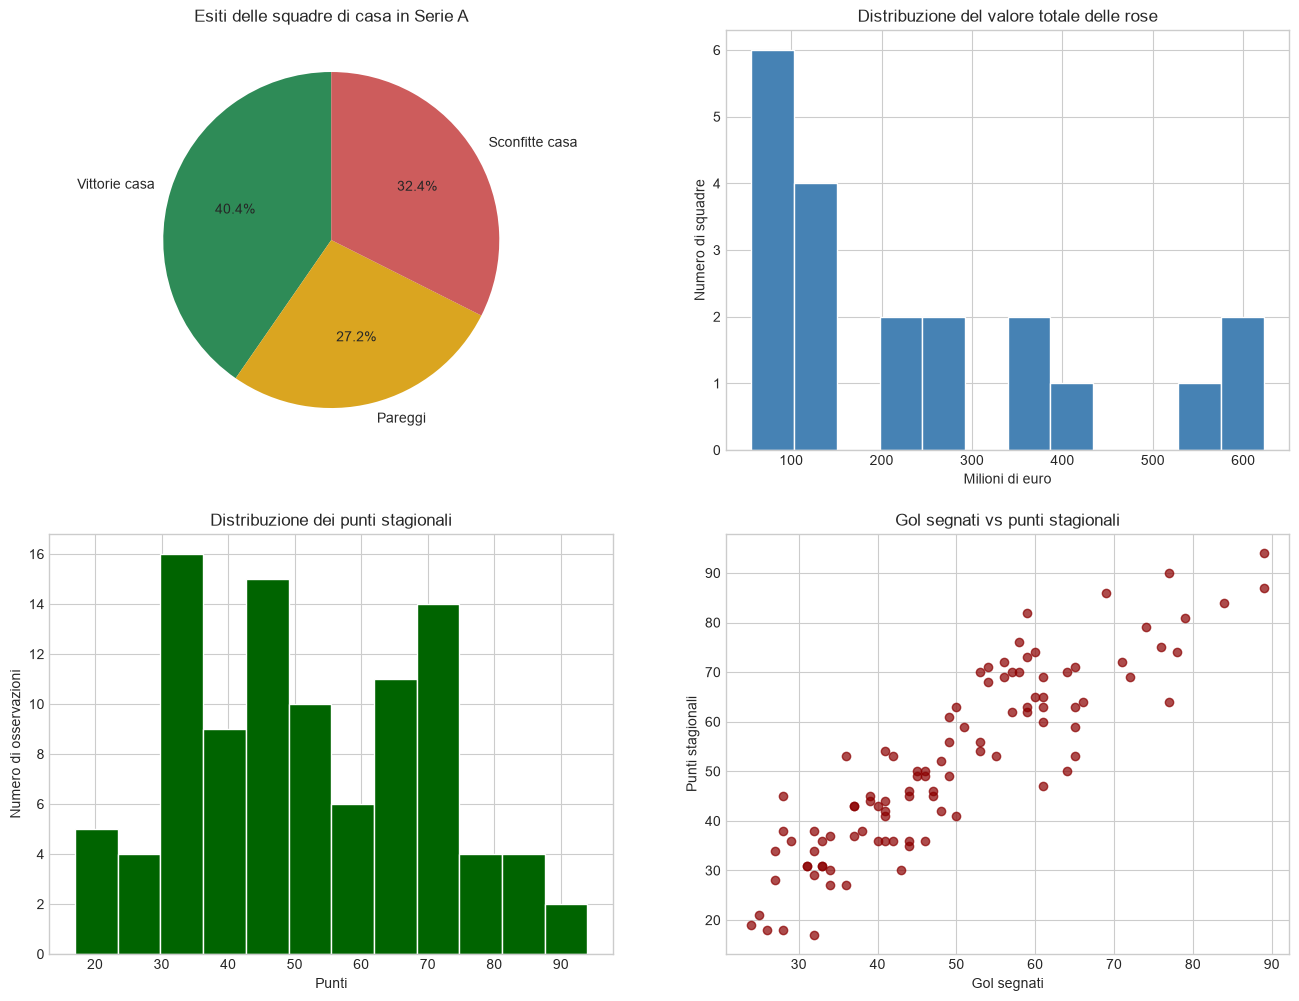

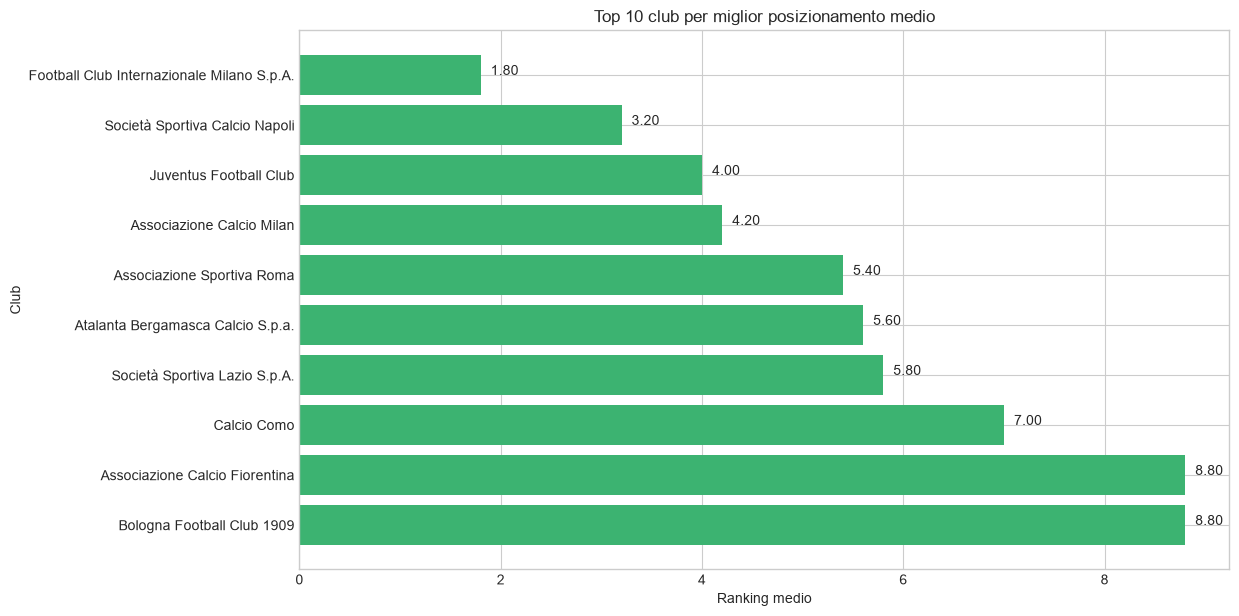

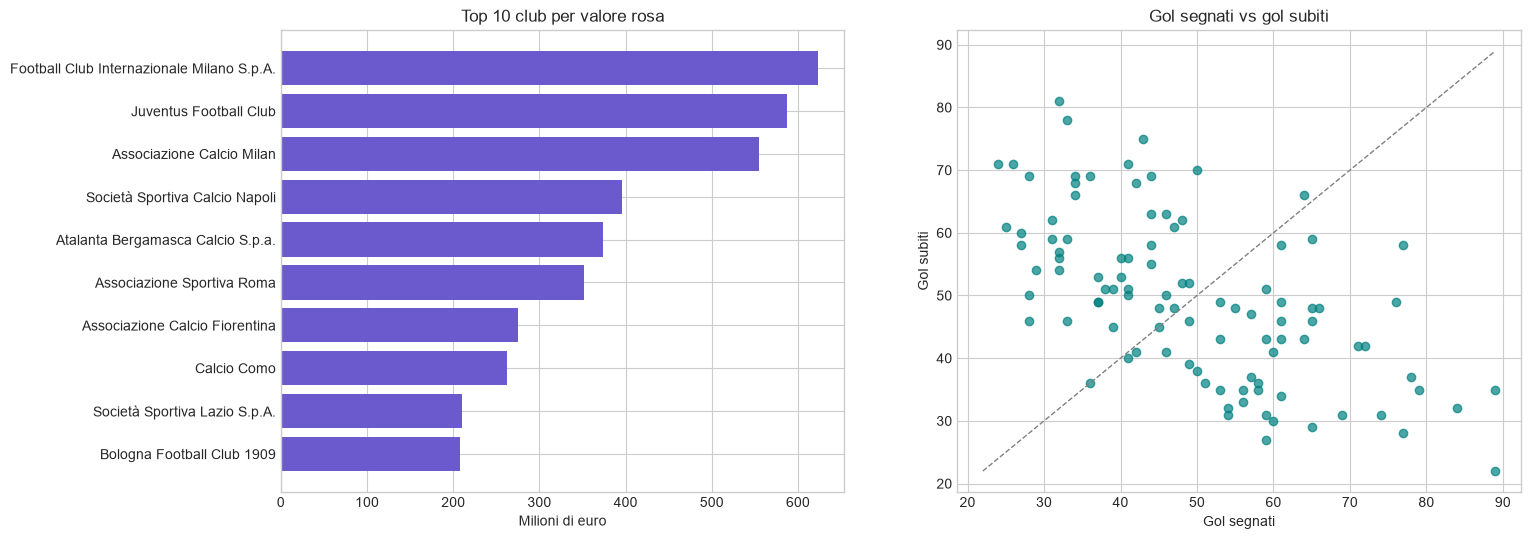

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].pie(home_result_counts.values, labels=home_result_counts.index, autopct='%1.1f%%', startangle=90, colors=['seagreen', 'goldenrod', 'indianred'])
axes[0, 0].set_title('Esiti delle squadre di casa in Serie A')

axes[0, 1].hist(team_eda['team_market_value'].dropna() / 1e6, bins=12, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Distribuzione del valore totale delle rose')
axes[0, 1].set_xlabel('Milioni di euro')
axes[0, 1].set_ylabel('Numero di squadre')

axes[1, 0].hist(eda_club_season['season_points'], bins=12, color='darkgreen', edgecolor='white')
axes[1, 0].set_title('Distribuzione dei punti stagionali')
axes[1, 0].set_xlabel('Punti')
axes[1, 0].set_ylabel('Numero di osservazioni')

axes[1, 1].scatter(eda_club_season['goals_scored'], eda_club_season['season_points'], alpha=0.7, color='darkred')
axes[1, 1].set_title('Gol segnati vs punti stagionali')
axes[1, 1].set_xlabel('Gol segnati')
axes[1, 1].set_ylabel('Punti stagionali')

plt.show()

fig, ax = plt.subplots(figsize=(12, 7))
top_average_ranking_plot = top_average_ranking.sort_values('ranking_mean', ascending=False)
ax.barh(top_average_ranking_plot['club_name'], top_average_ranking_plot['ranking_mean'], color='mediumseagreen')
ax.set_title('Top 10 club per miglior posizionamento medio')
ax.set_xlabel('Ranking medio')
ax.set_ylabel('Club')

for index, value in enumerate(top_average_ranking_plot['ranking_mean']):
    ax.text(value + 0.1, index, f'{value:.2f}')

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_market_plot = top_market.sort_values('team_market_value', ascending=True)

axes[0].barh(top_market_plot['club_name'], top_market_plot['team_market_value'] / 1e6, color='slateblue')
axes[0].set_title('Top 10 club per valore rosa')
axes[0].set_xlabel('Milioni di euro')

axes[1].scatter(eda_club_season['goals_scored'], eda_club_season['goals_conceded'], alpha=0.7, color='teal')
min_val = min(eda_club_season['goals_scored'].min(), eda_club_season['goals_conceded'].min())
max_val = max(eda_club_season['goals_scored'].max(), eda_club_season['goals_conceded'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', linewidth=1)
axes[1].set_title('Gol segnati vs gol subiti')
axes[1].set_xlabel('Gol segnati')
axes[1].set_ylabel('Gol subiti')

plt.show()


,correlazione_con_season_points
season_points,1.000000
points_per_game,1.000000
goal_difference,0.978358
home_points,0.934455
away_points,0.927273
goals_scored_per_game,0.891882
goals_scored,0.891882
prior_total_points,0.776830
prior_home_points,0.707449
prior_away_points,0.700246


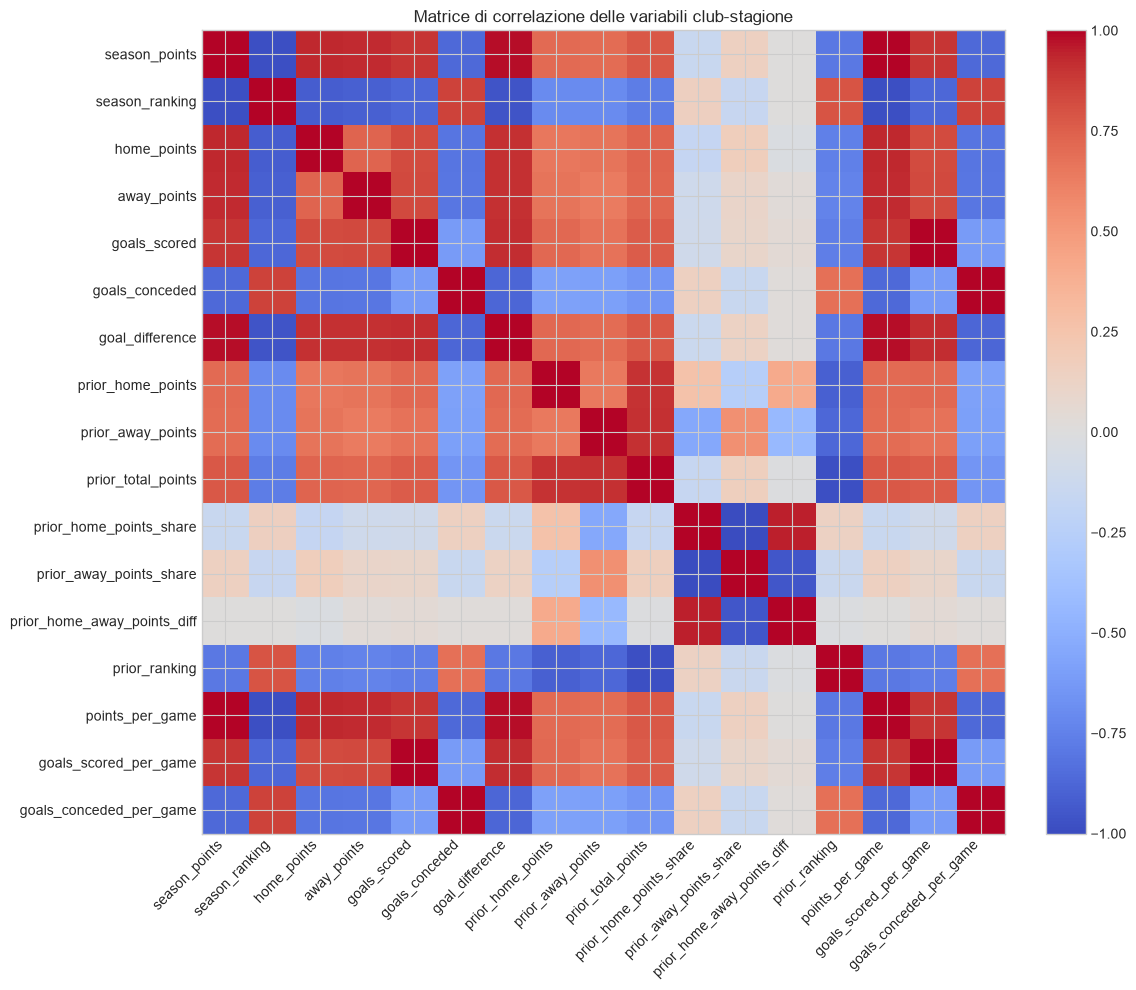

,correlazione_con_team_market_value
team_market_value,1.000000
top11_market_value,0.994020
top5_market_value,0.984459
national_team_players,0.802025
stadium_seats,0.683422
average_age,0.565727
foreigners_percentage,-0.004675
foreigners_number,-0.244485
squad_size,-0.696045


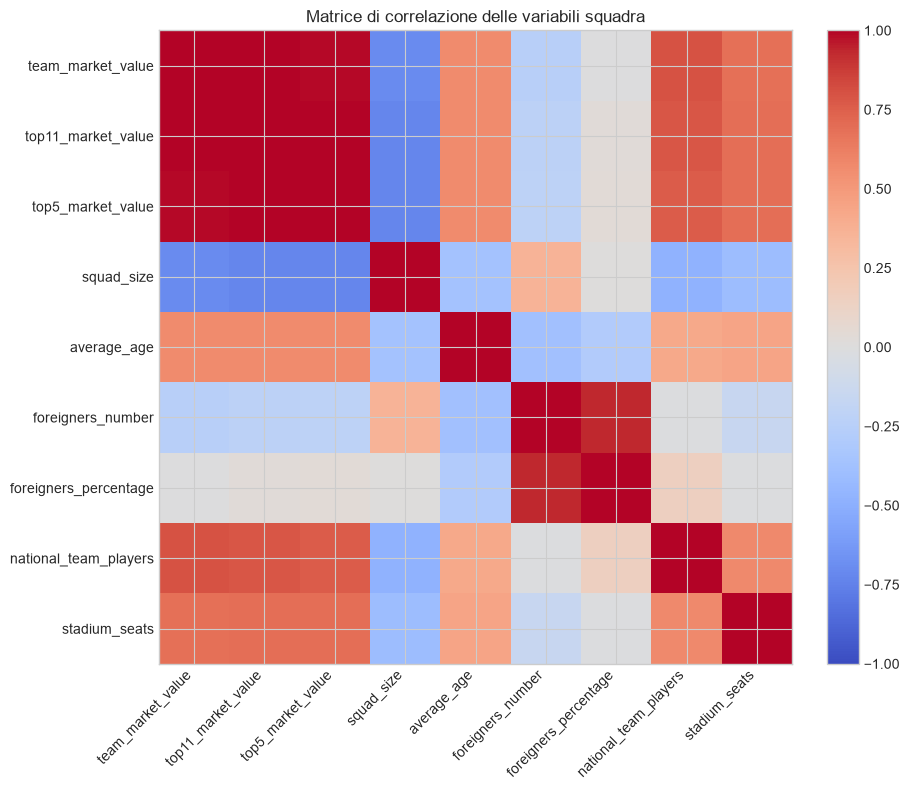

In [50]:
club_corr_cols = [
    'season_points', 'season_ranking', 'home_points', 'away_points', 'goals_scored', 'goals_conceded',
    'goal_difference', 'prior_home_points', 'prior_away_points', 'prior_total_points',
    'prior_home_points_share', 'prior_away_points_share', 'prior_home_away_points_diff', 'prior_ranking',
    'points_per_game', 'goals_scored_per_game', 'goals_conceded_per_game'
]
club_corr = eda_club_season[club_corr_cols].corr()
display(club_corr['season_points'].sort_values(ascending=False).to_frame('correlazione_con_season_points'))

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(club_corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(club_corr_cols)))
ax.set_yticks(range(len(club_corr_cols)))
ax.set_xticklabels(club_corr_cols, rotation=45, ha='right')
ax.set_yticklabels(club_corr_cols)
ax.set_title('Matrice di correlazione delle variabili club-stagione')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

team_corr_cols = [
    'team_market_value', 'top11_market_value', 'top5_market_value', 'squad_size', 'average_age',
    'foreigners_number', 'foreigners_percentage', 'national_team_players', 'stadium_seats'
]
team_corr = team_eda[team_corr_cols].corr()
display(team_corr['team_market_value'].sort_values(ascending=False).to_frame('correlazione_con_team_market_value'))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(team_corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(team_corr_cols)))
ax.set_yticks(range(len(team_corr_cols)))
ax.set_xticklabels(team_corr_cols, rotation=45, ha='right')
ax.set_yticklabels(team_corr_cols)
ax.set_title('Matrice di correlazione delle variabili squadra')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Preparazione dei dati per addestramento e validazione

Questa sezione costruisce il dataset per i modelli predittivi isolando `season_ranking` come variabile target e creando le variabili predittive principali: valore totale della rosa, punti e differenza reti della stagione precedente, top-11/top-5 per valore, net transfer spend, dimensione e profilo anagrafico della rosa, split casa/trasferta precedente e gol segnati/subiti.

Per ridurre leakage, il dataset principale usa le statistiche sportive della stagione precedente. I gol e la differenza reti della stagione corrente restano disponibili solo in un set diagnostico separato.

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils import resample

try:
    one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

target = 'ranking'

team_features = seriea_teams_values_5y.rename(columns={'name': 'club_name'}).drop_duplicates('club_name')[[
    'club_id', 'club_name', 'team_market_value', 'top11_market_value', 'top5_market_value',
    'squad_size', 'average_age', 'foreigners_number', 'foreigners_percentage',
    'national_team_players', 'stadium_seats'
]].copy()

prior_goal_features = eda_club_season[[
    'season', 'club_name', 'goals_scored', 'goals_conceded', 'goal_difference'
]].copy()
prior_goal_features['season'] = prior_goal_features['season'] + 1
prior_goal_features = prior_goal_features.rename(columns={
    'goals_scored': 'prior_goals_scored',
    'goals_conceded': 'prior_goals_conceded',
    'goal_difference': 'prior_goal_difference'
})

transfers = pd.read_csv('tables/transfers.csv')
transfers['transfer_fee'] = pd.to_numeric(transfers['transfer_fee'], errors='coerce').fillna(0)
transfers['transfer_season_start'] = transfers['transfer_season'].astype(str).str.extract(r'(\d{2})')[0]
transfers = transfers.dropna(subset=['transfer_season_start']).copy()
transfers['season'] = 2000 + transfers['transfer_season_start'].astype(int)

incoming_transfer_spend = transfers.groupby(['season', 'to_club_id'])['transfer_fee'].sum().reset_index().rename(columns={
    'to_club_id': 'club_id',
    'transfer_fee': 'incoming_transfer_spend_eur'
})
outgoing_transfer_income = transfers.groupby(['season', 'from_club_id'])['transfer_fee'].sum().reset_index().rename(columns={
    'from_club_id': 'club_id',
    'transfer_fee': 'outgoing_transfer_income_eur'
})
transfer_balance = incoming_transfer_spend.merge(
    outgoing_transfer_income,
    on=['season', 'club_id'],
    how='outer'
).fillna(0)
transfer_balance['net_transfer_spend_eur'] = (
    transfer_balance['incoming_transfer_spend_eur'] - transfer_balance['outgoing_transfer_income_eur']
)

model_dataset = eda_club_season.merge(
    team_features,
    on='club_name',
    how='left'
).merge(
    prior_goal_features,
    on=['season', 'club_name'],
    how='left'
).merge(
    transfer_balance[['season', 'club_id', 'net_transfer_spend_eur']],
    on=['season', 'club_id'],
    how='left'
)

prior_feature_cols = [
    'prior_total_points', 'prior_goal_difference', 'prior_ranking',
    'prior_home_points', 'prior_away_points', 'prior_home_points_share',
    'prior_away_points_share', 'prior_home_away_points_diff',
    'prior_goals_scored', 'prior_goals_conceded'
]
model_dataset['has_prior_serie_a_season'] = model_dataset['prior_total_points'].notna().astype(int)
model_dataset[prior_feature_cols] = model_dataset[prior_feature_cols].fillna(0)
model_dataset['net_transfer_spend_eur'] = model_dataset['net_transfer_spend_eur'].fillna(0)
model_dataset['ranking'] = model_dataset['season_ranking'].astype(int)

numeric_features = [
    'season',
    'team_market_value', 'top11_market_value', 'top5_market_value',
    'net_transfer_spend_eur',
    'squad_size', 'average_age', 'foreigners_number', 'foreigners_percentage',
    'national_team_players', 'stadium_seats',
    'prior_total_points', 'prior_goal_difference', 'prior_ranking',
    'prior_home_points', 'prior_away_points', 'prior_home_points_share',
    'prior_away_points_share', 'prior_home_away_points_diff',
    'prior_goals_scored', 'prior_goals_conceded',
    'has_prior_serie_a_season'
]
categorical_features = []

diagnostic_numeric_features = numeric_features + ['goals_scored', 'goals_conceded', 'goal_difference']
model_dataset = model_dataset.dropna(subset=[target]).copy()
max_season = model_dataset['season'].max()
train_df = model_dataset[model_dataset['season'] < max_season].copy()
test_df = model_dataset[model_dataset['season'] == max_season].copy()

X_train = train_df[numeric_features + categorical_features]
X_test = test_df[numeric_features + categorical_features]
y_train = train_df[target].astype(int)
y_test = test_df[target].astype(int)

transformers = [
    ('numeric', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features)
]
if categorical_features:
    transformers.append((
        'categorical',
        Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', one_hot_encoder)
        ]),
        categorical_features
    ))

preprocessor = ColumnTransformer(transformers=transformers)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)
prepared_feature_names = preprocessor.get_feature_names_out()

class_distribution = y_train.value_counts().sort_index()
imbalance_ratio = class_distribution.max() / class_distribution.min()

if imbalance_ratio > 1.5:
    train_prepared_df = pd.DataFrame(X_train_prepared, columns=prepared_feature_names)
    train_prepared_df[target] = y_train.to_numpy()
    max_class_size = class_distribution.max()
    balanced_parts = []
    for ranking_class, class_rows in train_prepared_df.groupby(target):
        balanced_parts.append(resample(
            class_rows,
            replace=True,
            n_samples=max_class_size,
            random_state=42
        ))
    train_balanced_df = pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)
    X_train_balanced = train_balanced_df.drop(columns=[target]).to_numpy()
    y_train_balanced = train_balanced_df[target].astype(int)
    balancing_strategy = 'random_oversampling'
else:
    X_train_balanced = X_train_prepared
    y_train_balanced = y_train
    balancing_strategy = 'none'

X_train_diagnostic = train_df[diagnostic_numeric_features + categorical_features]
X_test_diagnostic = test_df[diagnostic_numeric_features + categorical_features]

modeling_artifacts = {
    'model_dataset': model_dataset,
    'target': target,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'diagnostic_numeric_features': diagnostic_numeric_features,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'preprocessor': preprocessor,
    'X_train_prepared': X_train_prepared,
    'X_test_prepared': X_test_prepared,
    'X_train_balanced': X_train_balanced,
    'y_train_balanced': y_train_balanced,
    'prepared_feature_names': prepared_feature_names,
    'balancing_strategy': balancing_strategy
}

print('=== DATASET MODELLAZIONE ===')
display(pd.DataFrame({
    'rows': [model_dataset.shape[0], train_df.shape[0], test_df.shape[0]],
    'columns': [model_dataset.shape[1], X_train.shape[1], X_test.shape[1]]
}, index=['model_dataset', 'X_train', 'X_test']))

print('=== DISTRIBUZIONE TARGET NEL TRAINING SET ===')
display(class_distribution.to_frame('count'))
print(f'Imbalance ratio: {imbalance_ratio:.2f} | balancing_strategy: {balancing_strategy}')

print('=== SHAPE MATRICI PREPROCESSATE ===')
display(pd.DataFrame({
    'rows': [X_train_prepared.shape[0], X_test_prepared.shape[0], X_train_balanced.shape[0]],
    'columns': [X_train_prepared.shape[1], X_test_prepared.shape[1], X_train_balanced.shape[1]]
}, index=['X_train_prepared', 'X_test_prepared', 'X_train_balanced']))


=== DATASET MODELLAZIONE ===


,rows,columns
model_dataset,100,35
X_train,80,22
X_test,20,22


=== DISTRIBUZIONE TARGET NEL TRAINING SET ===


,count
ranking,
1,4
2,4
3,5
4,3
5,4
6,5
7,3
8,4
9,5


Imbalance ratio: 2.00 | balancing_strategy: random_oversampling
=== SHAPE MATRICI PREPROCESSATE ===


,rows,columns
X_train_prepared,80,22
X_test_prepared,20,22
X_train_balanced,120,22


## Addestramento, validazione e interpretazione dei modelli

Il ranking viene trattato come target regressivo ordinale: valori più bassi indicano una posizione migliore. I modelli vengono addestrati sul training set cronologico e validati sull'ultima stagione disponibile nel test set.

Le performance vengono confrontate tramite MSE, RMSE, MAE, errore relativo medio e coefficiente R². L'importanza delle variabili viene ricavata dai coefficienti della Ridge Regression e dalle feature importance dei modelli ad albero, senza imporre una priorità manuale alle feature.

,model,MSE,RMSE,MAE,relative_MAE,R2
2,Random Forest,11.137105,3.337230,2.793265,0.267298,0.662997
3,Gradient Boosting,12.785352,3.575661,2.897827,0.277304,0.613122
1,Ridge Regression,13.586550,3.685994,3.144269,0.300887,0.588878
0,Baseline mean,33.053125,5.749185,4.950000,0.473684,-0.000170


,season,club_name,ranking,Baseline mean_prediction,Ridge Regression_prediction,Random Forest_prediction,Gradient Boosting_prediction
80,2025,Football Club Internazionale Milano S.p.A.,1,10.38,0.15,3.25,3.14
81,2025,Società Sportiva Calcio Napoli,2,10.38,4.62,4.11,3.81
82,2025,Associazione Sportiva Roma,3,10.38,7.00,5.84,5.64
83,2025,Calcio Como,4,10.38,11.76,7.41,8.06
84,2025,Associazione Calcio Milan,5,10.38,2.15,4.26,5.01
85,2025,Juventus Football Club,6,10.38,4.15,3.44,3.63
86,2025,Atalanta Bergamasca Calcio S.p.a.,7,10.38,6.43,4.88,4.22
87,2025,Bologna Football Club 1909,8,10.38,10.27,7.89,7.30
88,2025,Società Sportiva Lazio S.p.A.,9,10.38,7.46,5.04,4.65
89,2025,Udinese Calcio,10,10.38,13.67,13.85,12.81


=== FEATURE PIU RILEVANTI SECONDO RIDGE REGRESSION ===


,feature,coefficient,abs_coefficient
1,numeric__team_market_value,-1.107594,1.107594
10,numeric__stadium_seats,-1.004753,1.004753
9,numeric__national_team_players,-1.000579,1.000579
6,numeric__average_age,-0.884673,0.884673
2,numeric__top11_market_value,-0.733418,0.733418
3,numeric__top5_market_value,-0.693341,0.693341
17,numeric__prior_away_points_share,-0.619798,0.619798
8,numeric__foreigners_percentage,0.348371,0.348371
21,numeric__has_prior_serie_a_season,-0.199578,0.199578
5,numeric__squad_size,-0.191400,0.191400


=== FEATURE MENO RILEVANTI SECONDO RIDGE REGRESSION ===


...

=== FEATURE PIU RILEVANTI SECONDO I MODELLI AD ALBERO ===


,model,feature,importance
25,Gradient Boosting,numeric__top5_market_value,0.352444
23,Gradient Boosting,numeric__team_market_value,0.269897
24,Gradient Boosting,numeric__top11_market_value,0.171213
26,Gradient Boosting,numeric__net_transfer_spend_eur,0.076554
32,Gradient Boosting,numeric__stadium_seats,0.021797
41,Gradient Boosting,numeric__prior_goals_scored,0.018284
42,Gradient Boosting,numeric__prior_goals_conceded,0.015768
31,Gradient Boosting,numeric__national_team_players,0.013935
28,Gradient Boosting,numeric__average_age,0.009667
27,Gradient Boosting,numeric__squad_size,0.007809


=== FEATURE MENO RILEVANTI SECONDO I MODELLI AD ALBERO ===


,model,feature,importance
43,Gradient Boosting,numeric__has_prior_serie_a_season,0.000073
29,Gradient Boosting,numeric__foreigners_number,0.000722
22,Gradient Boosting,numeric__season,0.000885
33,Gradient Boosting,numeric__prior_total_points,0.001163
35,Gradient Boosting,numeric__prior_ranking,0.001289
34,Gradient Boosting,numeric__prior_goal_difference,0.003051
40,Gradient Boosting,numeric__prior_home_away_points_diff,0.004638
38,Gradient Boosting,numeric__prior_home_points_share,0.005278
37,Gradient Boosting,numeric__prior_away_points,0.006046
36,Gradient Boosting,numeric__prior_home_points,0.006398


=== PRIMI LIVELLI DI UN DECISION TREE INTERPRETABILE ===
|--- numeric__top5_market_value <= -0.43
|   |--- numeric__team_market_value <= -0.65
|   |   |--- numeric__net_transfer_spend_eur <= 0.78
|   |   |   |--- value: [17.15]
|   |   |--- numeric__net_transfer_spend_eur >  0.78
|   |   |   |--- value: [13.00]
|   |--- numeric__team_market_value >  -0.65
|   |   |--- numeric__prior_home_points <= 0.39
|   |   |   |--- value: [12.64]
|   |   |--- numeric__prior_home_points >  0.39
|   |   |   |--- value: [16.00]
|--- numeric__top5_market_value >  -0.43
|   |--- numeric__squad_size <= -0.41
|   |   |--- numeric__prior_goals_scored <= 1.43
|   |   |   |--- value: [3.19]
|   |   |--- numeric__prior_goals_scored >  1.43
|   |   |   |--- value: [5.50]
|   |--- numeric__squad_size >  -0.41
|   |   |--- numeric__stadium_seats <= 0.07
|   |   |   |--- value: [9.56]
|   |   |--- numeric__stadium_seats >  0.07
|   |   |   |--- value: [6.08]



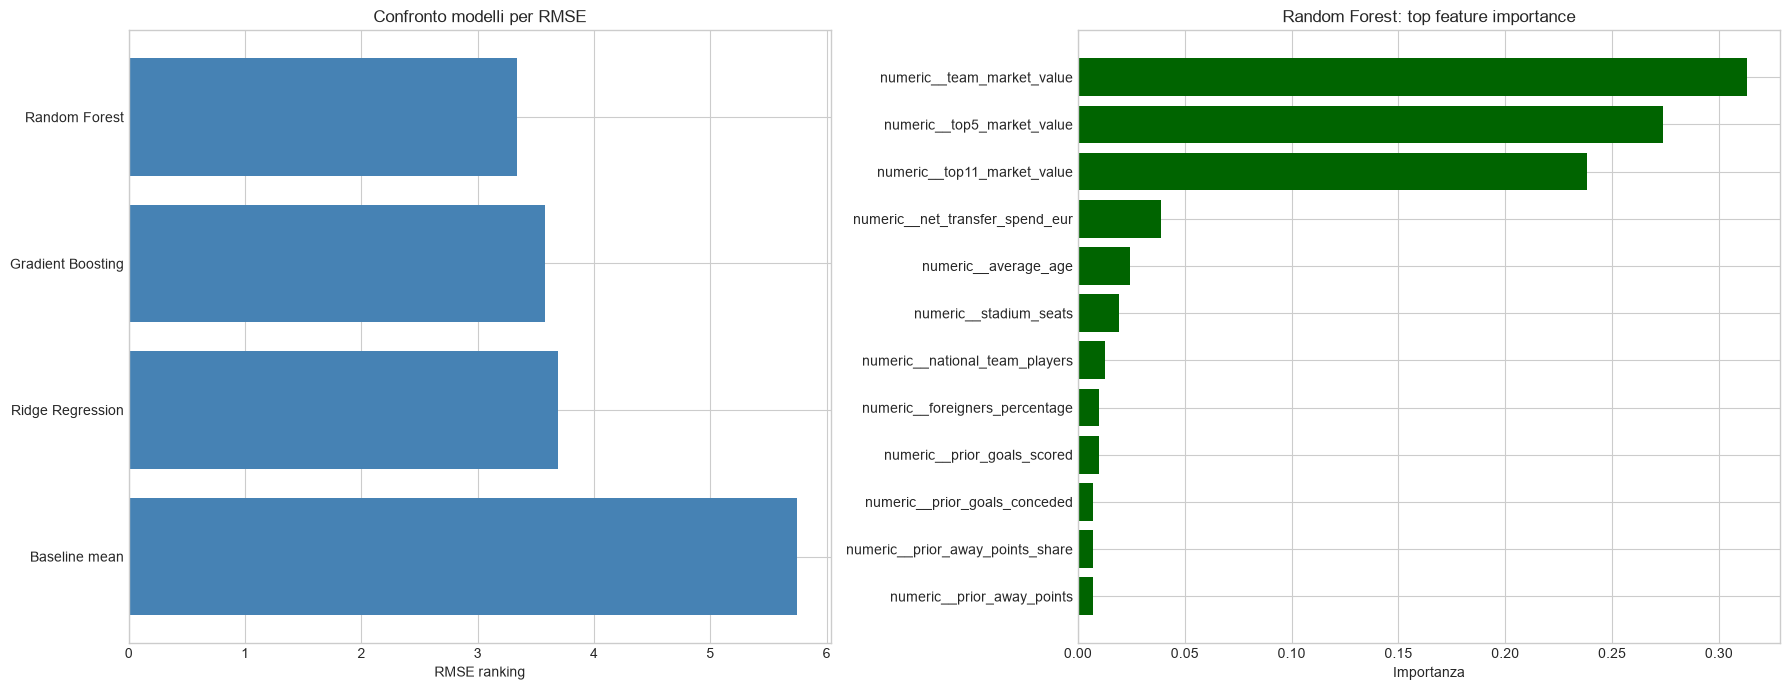

In [52]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, export_text

models = {
    'Baseline mean': DummyRegressor(strategy='mean'),
    'Ridge Regression': RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0]),
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=2,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

model_results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train_prepared, y_train)
    y_pred = model.predict(X_test_prepared)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    relative_mae = mae / y_test.mean()
    r2 = r2_score(y_test, y_pred)
    model_results.append({
        'model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'relative_MAE': relative_mae,
        'R2': r2
    })
    trained_models[model_name] = model

model_performance = pd.DataFrame(model_results).sort_values('RMSE')
display(model_performance)

predictions = test_df[['season', 'club_name', target]].copy()
for model_name, model in trained_models.items():
    predictions[f'{model_name}_prediction'] = model.predict(X_test_prepared).round(2)
display(predictions.sort_values(target))

ridge_model = trained_models['Ridge Regression']
ridge_coefficients = pd.DataFrame({
    'feature': prepared_feature_names,
    'coefficient': ridge_model.coef_,
    'abs_coefficient': abs(ridge_model.coef_)
}).sort_values('abs_coefficient', ascending=False)

print('=== FEATURE PIU RILEVANTI SECONDO RIDGE REGRESSION ===')
display(ridge_coefficients.head(15))

print('=== FEATURE MENO RILEVANTI SECONDO RIDGE REGRESSION ===')
display(ridge_coefficients.tail(15).sort_values('abs_coefficient'))

tree_importance_frames = []
for model_name in ['Random Forest', 'Gradient Boosting']:
    model = trained_models[model_name]
    tree_importance_frames.append(pd.DataFrame({
        'model': model_name,
        'feature': prepared_feature_names,
        'importance': model.feature_importances_
    }))

tree_feature_importances = pd.concat(tree_importance_frames, ignore_index=True)
tree_feature_importances = tree_feature_importances.sort_values(['model', 'importance'], ascending=[True, False])

print('=== FEATURE PIU RILEVANTI SECONDO I MODELLI AD ALBERO ===')
display(tree_feature_importances.groupby('model').head(15))

print('=== FEATURE MENO RILEVANTI SECONDO I MODELLI AD ALBERO ===')
display(tree_feature_importances.groupby('model').tail(15).sort_values(['model', 'importance']))

interpretable_tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=3, random_state=42)
interpretable_tree.fit(X_train_prepared, y_train)
print('=== PRIMI LIVELLI DI UN DECISION TREE INTERPRETABILE ===')
print(export_text(interpretable_tree, feature_names=list(prepared_feature_names), max_depth=3))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

best_model_name = model_performance.iloc[0]['model']
axes[0].barh(model_performance.sort_values('RMSE', ascending=False)['model'], model_performance.sort_values('RMSE', ascending=False)['RMSE'], color='steelblue')
axes[0].set_title('Confronto modelli per RMSE')
axes[0].set_xlabel('RMSE ranking')

best_tree_importances = tree_feature_importances[
    tree_feature_importances['model'] == 'Random Forest'
].head(12).sort_values('importance', ascending=True)
axes[1].barh(best_tree_importances['feature'], best_tree_importances['importance'], color='darkgreen')
axes[1].set_title('Random Forest: top feature importance')
axes[1].set_xlabel('Importanza')

plt.tight_layout()
plt.show()
